In [5]:
# SME ECL (Expected Credit Loss) Modeling

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# --- Load Data ---
df = pd.read_csv(r"../Data/sme_synthetic_credit_data_FULL.csv")

In [9]:
# Use pre-trained PD model output (probability of default)
# Assume you already have a calibrated model and have run it on the full dataset
df['pd'] = np.clip(np.random.beta(2, 8, size=len(df)), 0.01, 0.99)  # placeholder for actual PD predictions

# --- Step 2: Train LGD Model (for defaulted SMEs only) ---
df_lgd = df[df['default_in_12_mo'] == 1].copy()

features_lgd = [
    'cash_on_hand', 'debt_to_equity_ratio',
    'loan_utilization_rate', 'industry_default_rate', 'owner_credit_score'
]

X_lgd = df_lgd[features_lgd]
y_lgd = df_lgd['loss_given_default']

lgd_model = LinearRegression()
lgd_model.fit(X_lgd, y_lgd)

LinearRegression()

In [11]:
# Predict LGD for all SMEs
df['lgd'] = lgd_model.predict(df[features_lgd])
df['lgd'] = np.clip(df['lgd'], 0.01, 1.0)

In [13]:
# Calculate EAD (Exposure at Default) ---
df['ead'] = df['credit_limit'] * df['loan_utilization_rate']


In [15]:
# ---Compute ECL ---
df['ecl'] = df['pd'] * df['lgd'] * df['ead']

In [17]:
# --- Summary Statistics ---
print("\nPortfolio Expected Credit Loss: ${:,.2f}".format(df['ecl'].sum()))
print("Average ECL per SME: ${:,.2f}".format(df['ecl'].mean()))


Portfolio Expected Credit Loss: $699,002,267.10
Average ECL per SME: $6,990.02


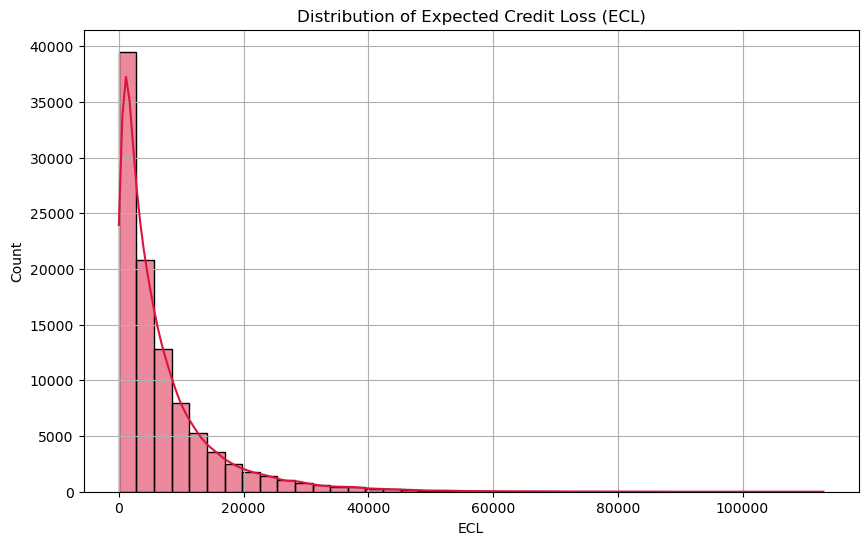

In [19]:
# --- Visualize ECL Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df['ecl'], bins=40, kde=True, color='crimson')
plt.title("Distribution of Expected Credit Loss (ECL)")
plt.xlabel("ECL")
plt.ylabel("Count")
plt.grid(True)
plt.show()

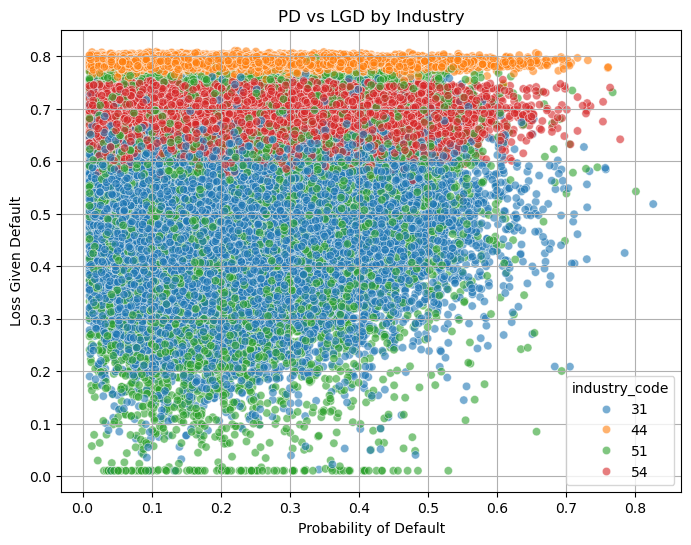

In [21]:
# --- Visualize PD vs LGD ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pd', y='lgd', hue='industry_code', palette='tab10', alpha=0.6)
plt.title("PD vs LGD by Industry")
plt.xlabel("Probability of Default")
plt.ylabel("Loss Given Default")
plt.grid(True)
plt.show()